# Baseline: прогнозирование стоимости недвижимости

**Задача:** Построить модель регрессии, которая предсказывает рыночную стоимость
объекта недвижимости на основе его характеристик.

**Датасет:** King County House Sales (Kaggle) — 104000 записей, 21 признак.

**Цель ноутбука:**
- Провести базовый анализ данных (EDA) и Feature Engineering.
- Обучить модель **HistGradientBoostingRegressor** на логарифмированном таргете.
- Оценить качество модели, проанализировать остатки и важность признаков (Permutation Importance).
- Сохранить обученную модель и список признаков для инференса.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print('OK')

OK


### 1. Загрузка данных

Загружаем исходный датасет и проверяем его размерность.

In [3]:
# 1. Загрузка данных (локальный файл из /data)
df = pd.read_csv('../data/table-data/buildings_prices.csv')
print(df.shape)
df.head()

(104000, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2116242585,20150204T000000,1379063.7,4,2.50,3650,7701,2.0,0,0,...,8,2260,1390,1994,0,98034,47.7228,-122.225,2950,7200
1,9310300185,20150325T000000,227000.0,2,1.00,1040,9100,1.0,0,0,...,7,1040,0,1937,0,98133,47.7407,-122.347,1950,13228
2,6414600232,20150420T000000,535000.0,3,2.25,2050,6648,1.0,0,0,...,7,1230,820,1990,0,98133,47.7258,-122.332,1760,7200
3,8443413733,20140520T000000,550000.0,3,2.50,2100,10881,2.0,0,0,...,7,2100,0,1947,0,98112,47.6259,-122.284,1950,10667
4,1166398796,20140515T000000,400000.0,3,2.50,1750,6480,1.0,0,0,...,7,1750,0,1924,2000,98040,47.5655,-122.188,1590,5390


### 2. Разведочный анализ данных (EDA)

Проверяем наличие пропусков, дубликатов, определяем типы данных и автоматически выделяем целевую колонку `price`.

In [4]:
# 2. EDA: пропуски, типы, целевая колонка
print('Пропуски:', df.isnull().sum().sum())
print('Дубликаты:', df.duplicated().sum())
print(df.dtypes)

# автоопределение target
target_col = [c for c in df.columns if 'price' in c]
target_col = target_col[0] if target_col else df.columns[-1]
print(f'Target: {target_col}')

# только числовые
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(f'Числовых: {len(num_cols)}')
non_num = set(df.columns) - set(num_cols)
if non_num: print(f'Нечисловые (исключены): {list(non_num)}')

Пропуски: 0
Дубликаты: 0
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object
Target: price
Числовых: 20
Нечисловые (исключены): ['date']


### 3. Распределение целевой переменной и корреляционный анализ

Визуализируем гистограмму и боксплот для `price`, чтобы оценить асимметрию и наличие выбросов.
Анализируем линейную связь числовых признаков с целевой переменной `price` и строим тепловую карту корреляций.

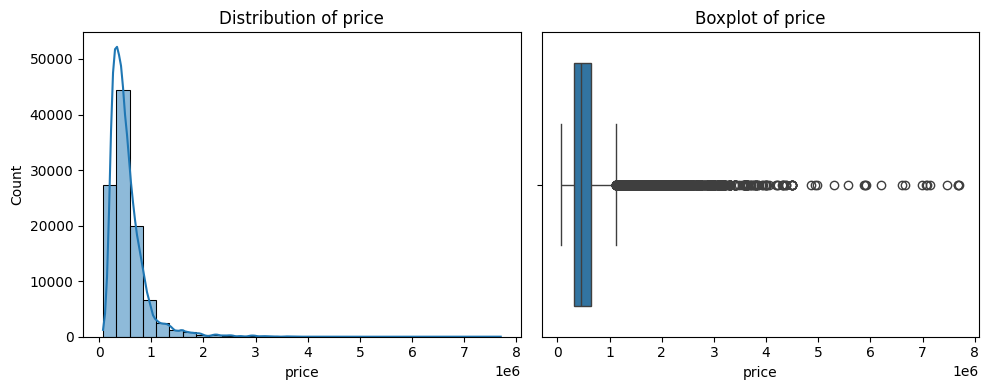

Mean: 538957.08
Median: 450000.00
Std: 359438.94


In [5]:
# 3. Распределение target
target_col = [c for c in df.columns if 'price' in c]
target_col = target_col[0] if target_col else df.columns[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df[target_col], bins=30, kde=True, ax=ax1)
ax1.set_title(f'Distribution of {target_col}')
sns.boxplot(x=df[target_col], ax=ax2)
ax2.set_title(f'Boxplot of {target_col}')
plt.tight_layout()
plt.show()

print(f'Mean: {df[target_col].mean():.2f}')
print(f'Median: {df[target_col].median():.2f}')
print(f'Std: {df[target_col].std():.2f}')

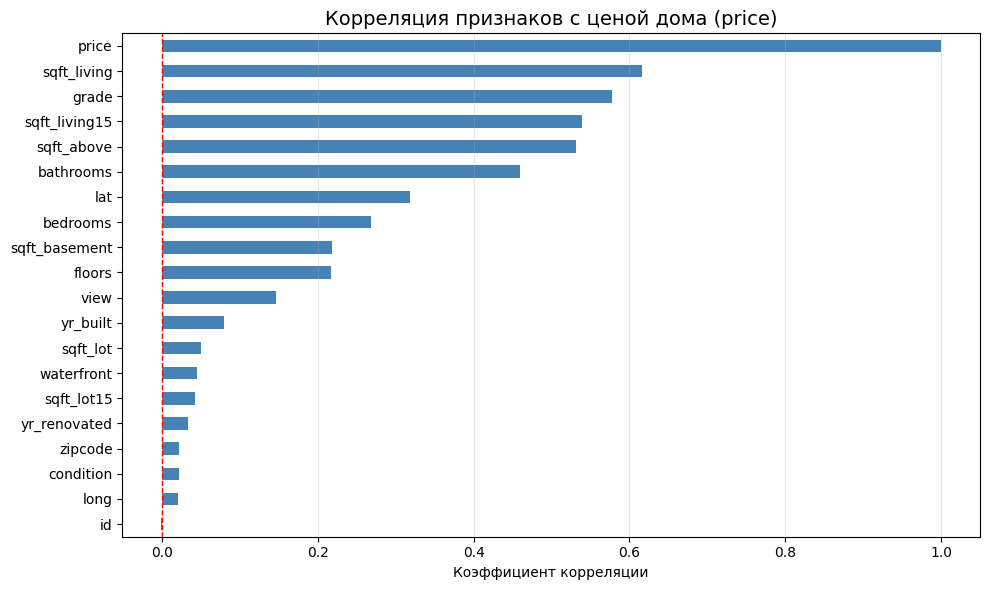

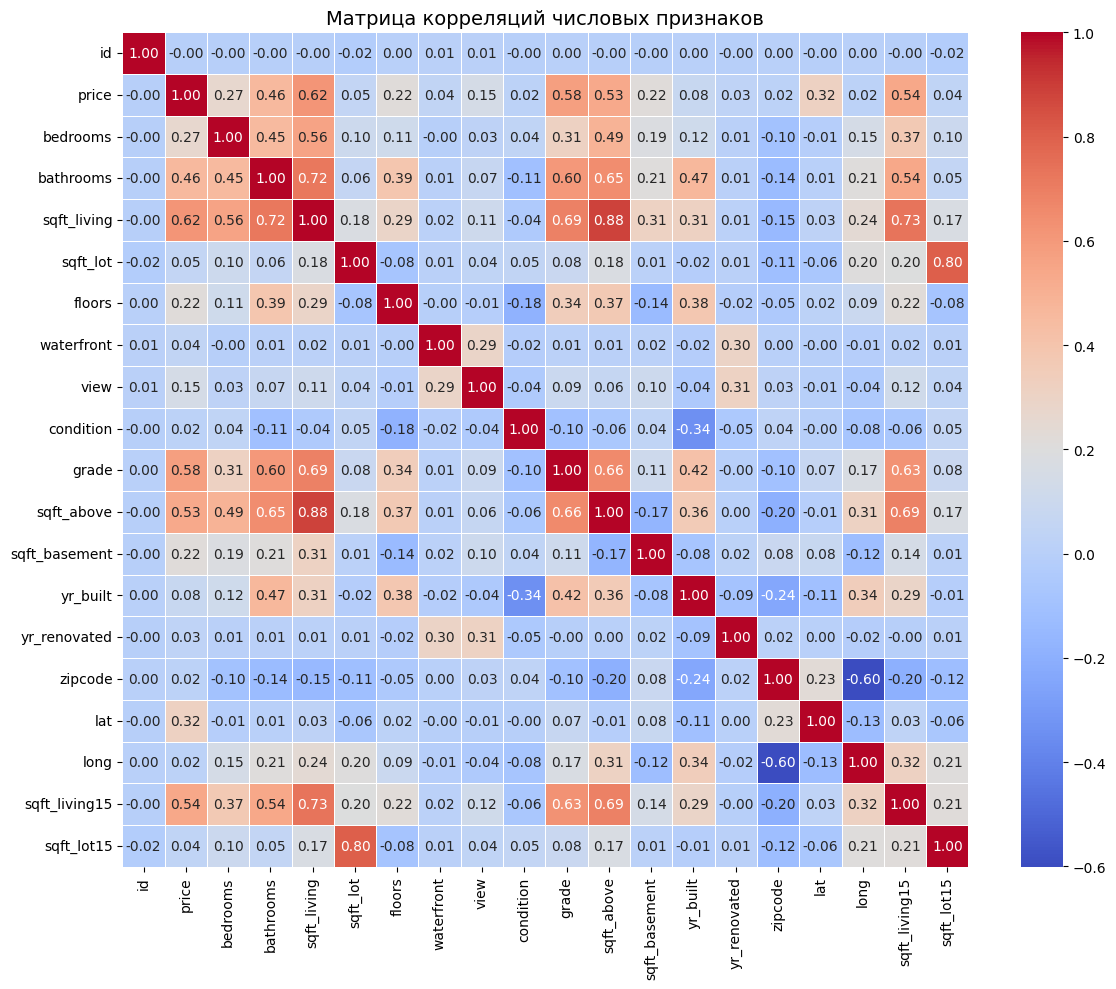

price            1.000000
sqft_living      0.616298
grade            0.578249
sqft_living15    0.538868
sqft_above       0.531292
bathrooms        0.459825
lat              0.317993
bedrooms         0.267845
sqft_basement    0.217803
floors           0.216443
view             0.146342
yr_built         0.079174
sqft_lot         0.050186
waterfront       0.044833
sqft_lot15       0.041786
yr_renovated     0.032823
zipcode          0.022354
condition        0.021819
long             0.020217
id              -0.000951
Name: price, dtype: float64


In [6]:
# 4. Корреляции (только числовые)
target_col = [c for c in df.columns if 'price' in c]
target_col = target_col[0] if target_col else df.columns[-1]
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

df_num = df[num_cols]

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_target = df_num.corr()[target_col].sort_values()
corr_with_target.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Корреляция признаков с ценой дома (price)', fontsize=14)
ax.set_xlabel('Коэффициент корреляции')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
corr = df_num.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

if target_col in corr.columns:
    print(corr[target_col].sort_values(ascending=False))

### 4. Генерация новых признаков (Feature Engineering)

Создаем дополнительные признаки:
**`is_renovated`** — бинарный признак проведения ремонта (1 — был ремонт, 0 — не было).
**`living_to_lot_ratio`** — отношение жилой площади к общей площади участка.

In [7]:
# признак ремонта и соотношение площадей

# 1. Факт реновации (1 - был ремонт, 0 - не было)
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

# 2. Отношение жилой площади к площади всего участка
df['living_to_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)

### 5. Подготовка данных

- Исключаем из признаков `price` и идентификатор `id` (чтобы избежать утечки данных).
- Делим выборку на Train / Test в соотношении 80/20.
- Логарифмируем целевую переменную (`np.log1p`), чтобы сгладить выбросы и нормализовать распределение.

In [8]:
# 5. Разделение на train/test
target_col = [c for c in df.columns if 'price' in c]
target_col = target_col[0] if target_col else df.columns[-1]
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)
# Исключаем id — он не должен влиять на предсказание
if 'id' in num_cols:
    num_cols.remove('id')

X = df[num_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features ({len(num_cols)}): {num_cols}')
print(f'Target: {target_col}')

Train: (83200, 20), Test: (20800, 20)
Features (20): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'is_renovated', 'living_to_lot_ratio']
Target: price


### 6. Обучение модели (HistGradientBoostingRegressor)

Обучаем градиентный бустинг, устойчивый к разным масштабам признаков

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 6. Обучение HistGradientBoosting регрессии
model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train_log)
y_pred = model.predict(X_test)

print('Model trained')

Model trained


### 7. Сохранение

Сохраняем обученную модель и список использованных признаков

In [10]:
# 7. Сохранение модели для инференса
import pickle
import os

# Сохраняем модель
model_path = '../models/model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Сохраняем список признаков (нужен для инференса)
features_path = '../models/model_features.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(list(X.columns), f)

print(f'Модель сохранена: {model_path} ({os.path.getsize(model_path)/1024:.1f} KB)')
print(f'Признаки сохранены: {features_path}')
print(f'\nДля загрузки модели в инференсе:')
print(f'  with open("{model_path}", "rb") as f:')
print(f'      model = pickle.load(f)')
print(f'  with open("{features_path}", "rb") as f:')
print(f'      features = pickle.load(f)')

Модель сохранена: ../models/model.pkl (369.0 KB)
Признаки сохранены: ../models/model_features.pkl

Для загрузки модели в инференсе:
  with open("../models/model.pkl", "rb") as f:
      model = pickle.load(f)
  with open("../models/model_features.pkl", "rb") as f:
      features = pickle.load(f)


### 8. Оценка качества модели

Возвращаем предсказания к исходной денежной шкале с помощью `np.expm1` и рассчитываем основные метрики качества (MAE, MSE, RMSE, R²).

In [11]:
# 8. Метрики
y_pred = np.expm1(y_pred)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = float(np.sqrt(mse))
r2 = r2_score(y_test, y_pred)

print('=' * 50)
print('METRICS')
print('=' * 50)
print(f'MAE:  {mae:,.2f}')
print(f'MSE:  {mse:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2:   {r2:.4f}')
print('=' * 50)
print(f'Model explains {r2*100:.1f}% of variance')

METRICS
MAE:  130,646.29
MSE:  49,645,675,960.79
RMSE: 222,813.10
R2:   0.6223
Model explains 62.2% of variance


### 9. Визуализация: Фактические и Предсказанные значения

График соответствия предсказанных цен реальным. (Красная пунктирная линия обозначает идеальное предсказание)

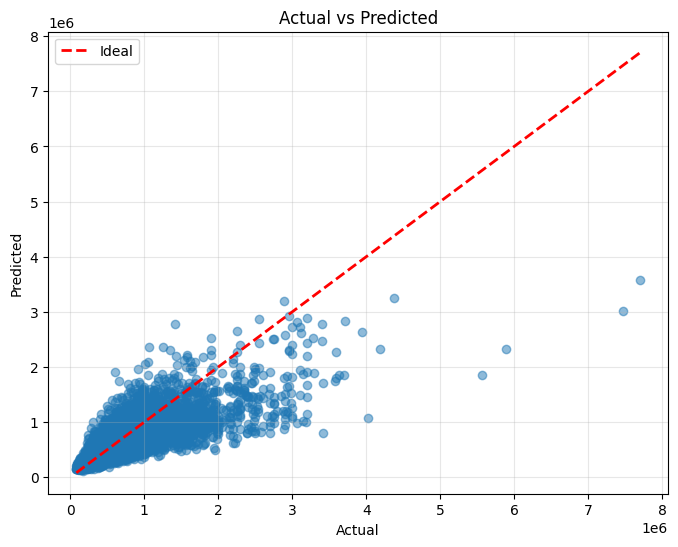

In [12]:
# 9. Факт vs предсказание
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 10. Анализ остатков (Residuals)

Исследуем ошибки модели, проверяем смещенность и распределение ошибок вокруг нуля.

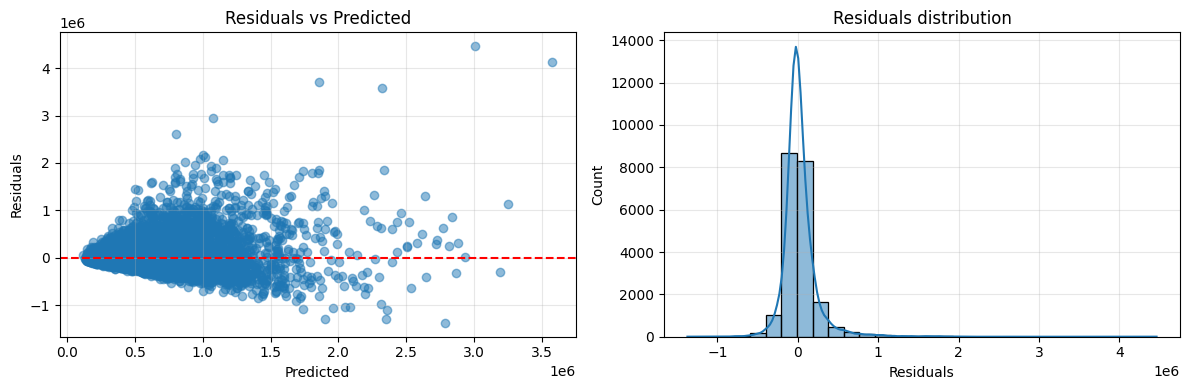

Mean residuals: 25091.26


In [13]:
# 10. Остатки
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='r', linestyle='--')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')
ax1.grid(alpha=0.3)

sns.histplot(residuals, bins=30, kde=True, ax=ax2)
ax2.set_xlabel('Residuals')
ax2.set_title('Residuals distribution')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Mean residuals: {residuals.mean():.2f}')

### 11. Оценка важности признаков (Permutation Importance)

Определяем, какие факторы оказывают наибольшее влияние на качество предсказаний на тестовой выборке.

In [14]:
from sklearn.inspection import permutation_importance

# Расчет важности признаков на тестовой выборке
result = permutation_importance(model, X_test, y_test_log, n_repeats=10, random_state=42)

# Создание DataFrame с результатами
feature_importance = pd.DataFrame({
    'Feature': num_cols,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

display(feature_importance)

,Feature,Importance
2,sqft_living,0.262925
14,lat,0.210672
8,grade,0.153111
16,sqft_living15,0.075269
11,yr_built,0.064609
19,living_to_lot_ratio,0.011625
0,bedrooms,0.009294
1,bathrooms,0.009260
15,long,0.005122
6,view,0.004771
